# Tarea N.3 Diferenciacion numerica

**Nombre: Arenas Limon Angel Daniel** 

In [4]:
import numpy as np
import matplotlib.pyplot as plt 
import scipy as sp

## 1. Diferenciacion numerica

Crea una funcion $f(x)$ que devuelva $\displaystyle{1 + \frac{1}{2} tanh(2x)}$, luego usa **diferencias centrales** para calcular numericamente la derivada de la funcion en el intervalo  $−2 ≤ x ≤ 2$. Despues, calcula la derivada analıticamente y haz una grafica con tu resultado numerico  y la respuesta analıtica en el mismo grafico. Puede resultar  util graficar la respuesta  exacta como l ́ıneas y la numerica como puntos. (Hint: usa la funcion tanh del paquete math.)

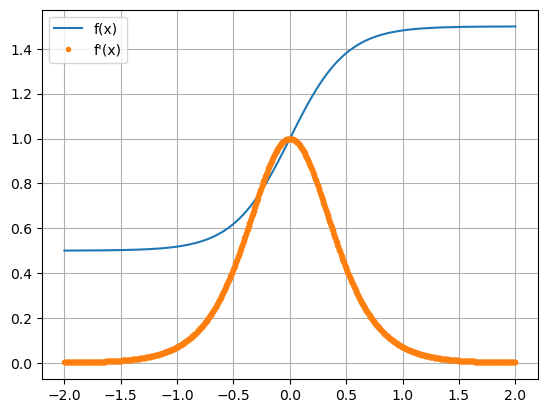

In [8]:
#funcion a derivar
def f(x):
  return 1+0.5*np.tanh(2*x)


#Difrenecial central
def dif(f,x,h):
  return (f(x+h/2)-f(x-h/2))/(h)

#x que queremos tomar.
X = np.linspace(-2,2,1000)

#Creamos una lista vacia para ir almacenando los valores
Df =[]

for x in X:
  #guardamos el valor obtenido de la diferencial en una variable
  y = dif(f,x,0.001)
  #guardamos el valor de la variable en nuestra lista creada.
  Df.append(float(y))

#Graficamos para ver como nos quedo
plt.plot(X, f(X), label='f(x)')
plt.plot(X, Df,'.', label="f'(x)")
plt.legend()
plt.grid()
plt.show()

## 2. Campo electrico de una distribucion de cargas

Supongamos que tenemos una distribucion de cargas y queremos calcular el campo electrico resultante. Una forma de hacerlo es calcular primero el potencial el  ectrico  $\Phi$ y luego tomar su gradiente. Para una carga puntual q en el origen, el potencial electrico a una distancia  $r$ del origen es $\Phi = q/4\pi \epsilon_0r$ y el campo electrico es  $\vec{E} = −\nabla \Phi$.

**a)** Suponiendo que tienes dos cargas, de $+1 C$ y $−1 C$ (respectivamente), separadas $10 [cm]$. Calcula el potencial electrico resultante en un plano cuadrado de $1[m]$ $×$ $1 [m]$ que rodea las cargas y pasa a traves de ellas. Calcula el potencial en puntos  ́ espaciados a $1 [cm]$ en una cuadrıcula y haz una visualizacion en la pantalla del potencial usando un grafico de densidad.  ́

In [2]:
def Potencial_dipolo(X,Y,S):
  #Creamos la malla de los valores que tomara nuestra funcion
  x,y = np.meshgrid(X,Y)
  ep_0 = 8.854187817e-12 # unidades [F*m^-1]
                          #Posiciones de medicion con respecto a donde este mi carga dependiendo del marco de referencia
  r_1 = np.sqrt((x+S/2)**2+(y)**2) #la posicion se la marco en Y porque con el mgrid es donde se mantiene constante en x variando y
  r_2 = np.sqrt((x-S/2)**2+(y)**2)
  # valores de las cargas
  q_1 = -1
  q_2 = 1
  k = 1/(4*np.pi*ep_0)
  #potenciales individuales debido a las cargas.
  phi1 = k*q_1/(r_1)
  phi2 = k*q_2/(r_2)
 
  return phi1+phi2

Text(0, 0.5, 'y')

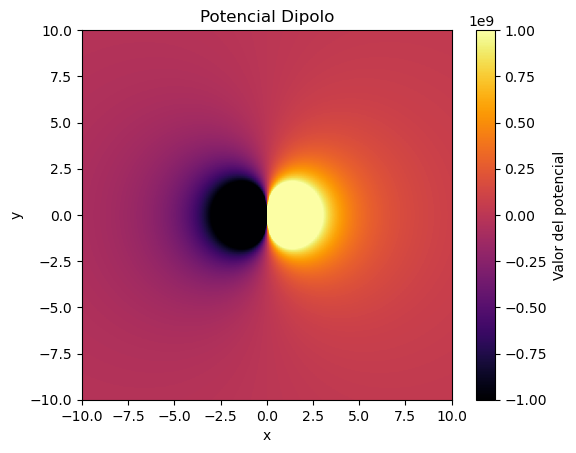

In [6]:
"--Datos para cambiar en el grafico----------------------------------------------------------------------------------------------------------------------------------------"
Ventana = 10 # variable cambia el intervalopara visualizar el potencial
N=200 # numero de datos tanto en X como en Y
Cota=1e9 # variable cota:= los valores que puede tener la grafica en [-cota,cota] y no sean mayores a ese valor
S=1 #distancia entre las cargas.
"----programa-------------------------------------------------------------------------------------------------------------------------------------------------------"
X=np.linspace(-Ventana,Ventana,N)
Y=np.linspace(-Ventana,Ventana,N)
P=Potencial_dipolo(X,Y,S)
"-----Grafica de potencial----------------------------------------------------------------------------------------------------------------------------------------"
plt.title("Potencial Dipolo")
#para imshow el primer termino es el del valor a graficar, el segundo es el valor maximo que puede alcanzar la función
#el tercero la cota inferior el cuarto son los intervalos de nuestros que abarcara la imagen, el cmap. cambias el tipo de formato de color para mejor visualización.
plt.imshow(P,vmax=Cota,vmin=-Cota,extent=(-Ventana,Ventana,-Ventana,Ventana), cmap ='inferno')
plt.colorbar(label='Valor del potencial')
plt.xlabel('x')
plt.ylabel('y')

**b)** Ahora calcula las derivadas parciales del potencial con respecto a $x$ y $y$, para encontrar el campo electrico en el plano  $xy$ y realiza una visualizacion de dicho campo.


Lo anterior es un poco mas complicado que visualizar el potencial, porque el  campo electrico tiene  **magnitud y direccion**. Una forma de hacerlo podrıa ser hacer dos graficos de densidad, uno para la magnitud y otro para la direccion, este ultimo usando el esquema de color "hsv” en pylab, que es un esquema de arcoıris que pasa por todos los colores pero comienza y termina con el mismo tono de rojo, lo que lo hace adecuado para representar cosas como direcciones o angulos que dan la vuelta al cırculo completo y terminan donde comenzaron. Una
visualizacion mas sofisticada podrıa usar el objeto de flecha del paquete visual, dibujando una cuadrıcula de flechas con la direccion y la longitud elegidas para representar el campo.

In [10]:
#Creamos las funciones para hacer las derivadas parciales
def Parcial_x(f,x,y,h):
  return (f(x+h/2,y)-f(x-h/2,y))/(h)

def Parcial_y(f,x,y,h):
  return (f(x,y+h/2)-f(x,y-h/2))/(h)

#creamos una nueva funcion que no sea un arreglo para poder derivar.
def Potencial_dipolo3(x,y):
  ep_0 = 8.854187817e-12 # unidades [F*m^-1]
  #Posiciones de medicion con respecto a donde este mi carga dependiendo del marco de referencia
  r_1 = np.sqrt((x+0.5)**2+(y)**2) #Recordemos que la posicion de la particula para calcular su potencias es (x-x_0) y x_0=-0.5
  r_2 = np.sqrt((x-0.5)**2+(y)**2)
  # valores de las cargas
  q_1 = -1
  q_2 = 1
  #potenciales individuales debido a las cargas.
  phi1 = q_1/(4*np.pi*ep_0*r_1)
  phi2 = q_2/(4*np.pi*ep_0*r_2)
  return phi1+phi2

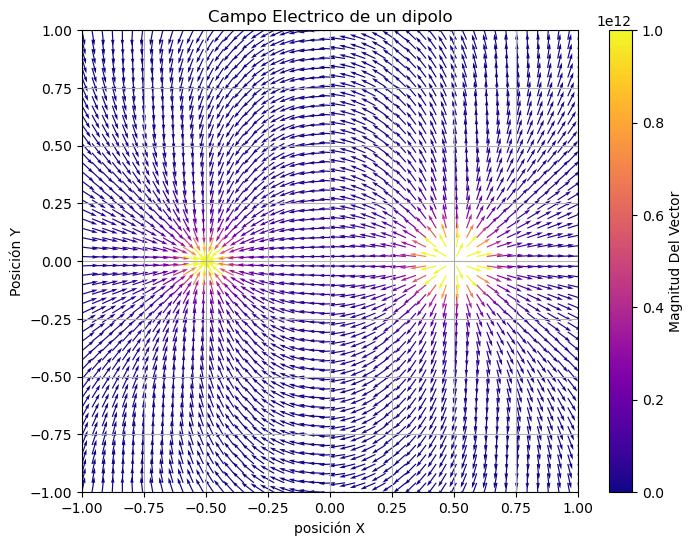

In [12]:
dis=1 #Variable para ajustar los valores de la grafica. 


X1=np.linspace(-dis,dis,50) #origen de los vectores
Y1=np.linspace(-dis,dis,50)

#Listas para hacer la malla en la grafica 
X=[]
Y=[]  
#listas para los vectores de la maya 
EX = []
EY = []


for x in X1:
  for y in Y1:
    #Dado que tenemos que tener un arreglo de 9 elementos y no de 3 (dado por las coordenadas)
    X.append(float(x))
    Y.append(float(y))
    #Calculamos los campos electricos debidos al potencial 
    w = -Parcial_x(Potencial_dipolo3,x,y,0.01)
    EX.append(float(w))
    w2 =-Parcial_y(Potencial_dipolo3,x,y,0.01)
    EY.append(float(w2)) 
      
#Listas con el cuadrado de cada elemento de cada vector
EX1 = [x**2 for x in EX]
EY1 = [y**2 for y in EY]
  
Norm=[np.sqrt(x+y) for x, y in zip(EX1,EY1)] #magnitud del vector a mostrar

#Normalizamos las componentes de los vectores para que se visualice de mejor manera 
EX_N = [x/v for x, v in zip(EX,Norm)]
EY_N = [y/v for y, v in zip(EY,Norm)]   
# Crear el gráfico de vectores
plt.figure(figsize=(8, 6))
#cota superior de la magnitud de los vectores 
c=1e12



flujo = plt.quiver(X, Y, EX_N, EY_N,Norm, cmap='plasma',scale=15, scale_units='xy', angles='xy',clim=(0,c))
#Comando para mostrar la barra de colores 
plt.colorbar(flujo, label='Magnitud Del Vector')

# Ajustar límites
plt.xlim(-dis, dis)
plt.ylim(-dis, dis)

# Título y etiquetas
plt.title("Campo Electrico de un dipolo")
# Mostrar el gráfico
plt.xlabel("posición X")
plt.ylabel("Posición Y") 
plt.grid(True)
plt.show()

**c)** Ahora supongamos que tenemos una distribucion continua de carga sobre un cuadrado de $L × L$. La densidad de carga en $\displaystyle{\frac{C}{m^2}}$ es:

\begin{align}
    \sigma(x,y) = q_0 Sen\left( \frac{2 \pi x}{L} \right)  Sen\left( \frac{2 \pi y}{L} \right)
\end{align}

Calcula y visualiza el campo electrico resultante en puntos espaciados a $1 [cm]$ en  $1$ metro cuadrado del plano $xy$ para el caso donde $L = 10 [cm]$. La distribucion de  carga esta centrada en el medio del  area visualizada y  $q_0 = 100 \frac{C}{m^2}$ .

Tendras que realizar una integral doble sobre  $x$ y $y$, luego diferenciar el potencial respecto a la posicion para obtener el campo el ectrico. Elige cualquier metodo de integracion que parezca apropiado para las integrales.

In [34]:
#definimos la funcion a integrar
def Diferencial_Potencial(x,y,a,b):
  q_0 = 100
  L = 10
  return q_0*np.sin(2*np.pi*x/L)*np.sin(2*np.pi*y/L)*((a-x)**2 + (b-y)**2)**(-1/2)

def Potencial(d,a,b,a1,b1):
  N = 50
  #Pesos y raices 
  x, w = np.polynomial.legendre.leggauss(N)
  #ajustamos pesos y raices 
  xp = 0.5*(b1-a1)*x + 0.5*(b1+a1)
  wp = 0.5*(b1-a1)*w
  s = 0
  for i in range(N):
        for j in range(N):
            s+=wp[i]*wp[j]*d(xp[i],xp[j],a,b)
  return s 
  
#ahora buscamos derivar esto con las funciones parciales con los puntos que creamos con los linspace

Text(0, 0.5, 'y')

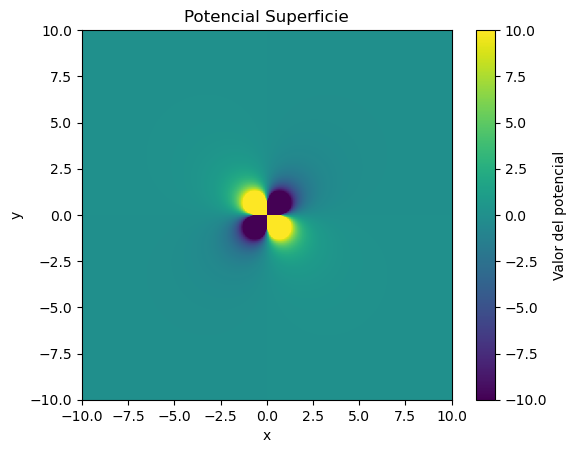

In [75]:
v=100
n=200
Y=np.linspace(-v,v,n)
X=np.linspace(-v,v,n)
L=5
x,y = np.meshgrid(X,Y)
Datos=Potencial(Diferencial_Potencial,x,y,-L,L)
dis=10
#esta acota los valores que puede tener la funcion 
c=10
plt.title("Potencial Superficie")
#para imshow el primer termino es el del valor a graficar, el segundo es el valor maximo que puede alcanzar la función
#el tercero son los intervalos de nuestros que abarcara la imagen, el cmap. cambias el tipo de formato de color para mejor visualización.
plt.imshow(Datos,vmax=c,vmin=-c,extent=(-dis,dis,-dis,dis), cmap ='viridis')
plt.colorbar(label='Valor del potencial')
plt.xlabel('x')
plt.ylabel('y')

In [45]:
def Campo(P,h):
    #se agregan listas para almacenar datos a Y constante
    Parcial_X=[]
    Parcial_Y=[]
    for y in range(len(X)):
      #se agregan listas vacias para X variable
      PX=[]
      PY=[]
      #codigo explicado anteriormente de los condicionales
      for x in range(len(X)):
        #Variables por que ocupe para cambiar los indices.
        i=y
        j=x
        
        if i==0:
          if j==0:
            Parcial_y = -(P[j+1][j]-P[i][j])/(h)
            Parcial_x = -(P[i][j+1]-P[i][j])/(h)
            PX.append(Parcial_x)
            PY.append(Parcial_y)
          elif j==len(X)-1:
            Parcial_y = -(P[i+1][j]-P[i][j])/(h)
            Parcial_x = -(P[i][j]-P[i][j-1])/(h)
            PX.append(Parcial_x)
            PY.append(Parcial_y)
          else :
            Parcial_y = -(P[i+1][j]-P[i][j])/(h)
            Parcial_x = -(P[i][j+1]-P[i][j-1])/(2*h)
            PX.append(Parcial_x)
            PY.append(Parcial_y)
        elif i==len(X)-1:
          if j==0:
            Parcial_y = -(P[i][j]-P[i-1][j])/(h)
            Parcial_x = -(P[i][j+1]-P[i][j])/(h)
            PX.append(Parcial_x)
            PY.append(Parcial_y)
          elif j==len(X)-1:
            Parcial_y =- (P[i][j]-P[i-1][j])/(h)
            Parcial_x = -(P[i][j]-P[i][j-1])/(h)
            PX.append(Parcial_x)
            PY.append(Parcial_y)
          else:
            Parcial_y = -(P[i][j]-P[i-1][j])/(h)
            Parcial_x = -(P[i][j+1]-P[i][j-1])/(2*h)
            PX.append(Parcial_x)
            PY.append(Parcial_y)
        elif 0 < i < len(X)-1:
          if j==0:
            Parcial_y = -(P[i+1][j]-P[i-1][j])/(2*h)
            Parcial_x = -(P[i][j+1]-P[i][j])/(h)
            PX.append(Parcial_x)
            PY.append(Parcial_y)
          elif j==len(X)-1 :
            Parcial_y = -(P[i+1][j]-P[i-1][j])/(2*h)
            Parcial_x = -(P[i][j]-P[i][j-1])/(h)
            PX.append(Parcial_x)
            PY.append(Parcial_y)
          elif 0 < j< len(X)-1:
            Parcial_y = -(P[i+1][j]-P[i-1][j])/(2*h)
            Parcial_x = -(P[i][j+1]-P[i][j-1])/(2*h)
            PX.append(Parcial_x)
            PY.append(Parcial_y)
      Parcial_X.append(PX)
      Parcial_Y.append(PY)
    return Parcial_X,Parcial_Y
        

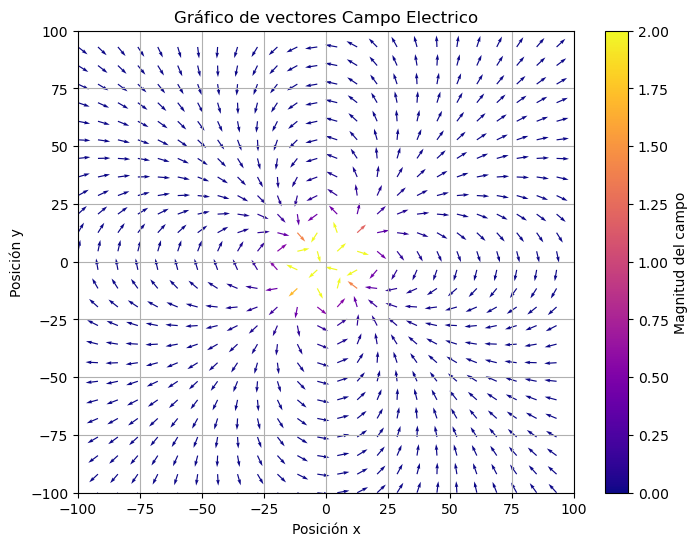

In [47]:
v=100
h=(max(X)-min(X))/len(X)
P=Campo(Datos,h)
p=5
c=2
s=8 #saltos en los arreglos


#Normalizar las componentes (para que todos los vectores tengan módulo 1)
Norm = np.sqrt(np.array(P[0])**2 + np.array(P[1])**2)
 # Para evitar divisiones por cero
EX_N = P[0] / Norm
EY_N = P[1] / Norm
xc=x[1:-1,1:-1]
yc=y[1:-1,1:-1]
# tamaño de la imagen
plt.figure(figsize=(8, 6))
quiver = plt.quiver(x[::s,::s],y[::s,::s] , EX_N[::s,::s], EY_N[::s,::s],Norm[::s,::s] , cmap='plasma', scale=1/p,scale_units='xy', angles='xy',clim=(0,c))
#Barra de colores para la magnitud de los vectores
plt.colorbar(quiver, label='Magnitud del campo')
# Ajustar límites y formato
plt.title("Gráfico de vectores Campo Electrico")
plt.xlabel("Posición x")
plt.ylabel("Posición y")
# Ajustar límites
plt.xlim(-v, v)
plt.ylim(-v, v)
#mostrar cuadricula
plt.grid()
plt.show()

**3. Procesamiento de imagenes y STM** 

Cuando la luz incide sobre una superficie, la cantidad que cae por unidad de area  ́
depende no solo de la intensidad de la luz, sino tambien del  angulo de incidencia.Si la luz forma un angulo $\theta$ con la normal, solo “ve” una fraccion $cos\theta$ de area, por unidad de area real en la superficie:  

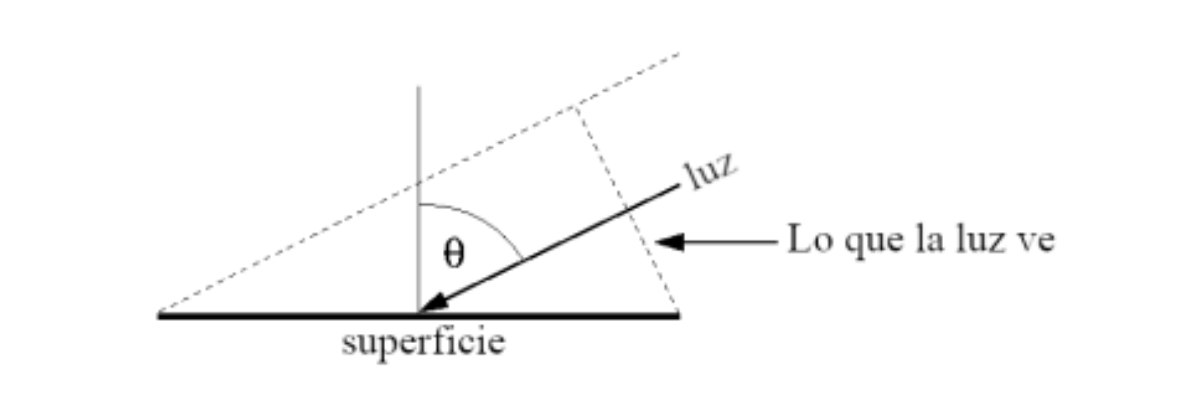

Ası, la intensidad de la iluminacion es  $a(cos \theta)$, si a es la intensidad bruta de la luz. Esta simple ley fısica es un elemento central de los graficos por computadora en 3D. Nos permite calcular como incide la luz sobre objetos tridimensionales y, por tanto, como seeran cuando se iluminen desde varios angulos.

Supongamos, por ejemplo, que miramos la Tierra desde arriba y vemos sus montanas. Conocemos la altura de las montanas  $w(x, y)$ en funcion de la posicion en el plano, por lo que la ecuacion para la superficie de la Tierra es simplemente $z = w(x, y)$, o
equivalentemente $w(x, y) − z = 0$, y el vector normal $v$ a la superficie esta dado por el gradiente de $w(x, y) − z$ de la siguiente manera:

\begin{align}
    \vec{v} = \nabla \left[w(x,y) - z\right]=
    \begin{pmatrix} 
        \partial/\partial x\\
        \partial/\partial y\\
        \partial/\partial z
    \end{pmatrix}
    \left[w(x,y) - z\right] = 
    \begin{pmatrix} 
        \partial/\partial x\\
        \partial/\partial y\\
        -1
    \end{pmatrix}
\end{align}

Ahora supongamos que tenemos luz entrante representada por un vector $\vec{a}$ con magnitud igual a la intensidad de la luz. Entonces el producto escalar de los vectores $\vec{a}$ y $\vec{v}$ es:

\begin{align}
    \vec{a} \cdot \vec{v} = |\vec{a}||\vec{v}| Cos\theta
\end{align}

donde $\theta$ es el angulo entre los vectores.  

Entonces, la intensidad de la iluminacion de la superficie de las montañas es:

\begin{align}
    I = |\vec{a}|Cos\theta = \frac{\vec{a} \cdot \vec{v}}{|\vec{v}|} = \frac{a_x(\partial w/\partial x) + a_y(\partial w/\partial y) - a_z}{\sqrt{(\partial w/\partial x)^2 + (\partial w/\partial y) + 1}}
\end{align}

Tomemos un caso simple donde la luz brilla horizontalmente con intensidad unitaria,a lo largo de una lınea en un angulo $\varphi$ en sentido contrario a las manecillas del reloj desde el eje $este-oeste$, de modo que $\vec{a} = (cos(\varphi), sen(\varphi), 0)$. Entonces nuestra intensidad de iluminacion se simplifica a:

\begin{align}
    I = \frac{Cos\varphi (\partial w/\partial x) + Sen \varphi(\partial w/\partial y)}{\sqrt{(\partial w/\partial x)^2 + (\partial w/\partial y)^2 + 1}}
\end{align}

Ası, si podemos calcular las derivadas de la altura w(x, y) y sabemos $\varphi$, entonces podemos calcular la intensidad en cualquier punto.

**a)** El archivo adjunto altitudes.txt, contiene la altitud $w(x, y)$ en metros sobre el nivel del mar (o profundidad bajo el nivel del mar) de la superficie de la Tierra, medida en una cuadrıcula de puntos $(x, y)$. Escribe un programa que lea este archivo y almacene los datos en una matriz. Luego calcula las derivadas $\partial w/\partial x$ y $\partial w/\partial y$ en cada punto de la cuadrıcula. Explica que metodo utilizaste para calcularlos y por que. (Hint: probablemente tendras que usar mas de un metodo para obtener cada punto de la cuadıcula porque suceden cosas incomodas en los bordes de la misma). Para calcular las derivadas, necesitaras saber el valor de $h$ y
la distancia en metros entre puntos de la cuadrıcula, que es de aproximadamente 30, 000 m en este caso.

In [51]:
# 1) Cargar altitudes
alturas = np.loadtxt('altitudes.txt')
h=3000

# Exageración vertical (opcional) para realzar las pendientes
vertical_exaggeration = 100
print(alturas[0][0])

-4116.06


Text(0, 0.5, 'y')

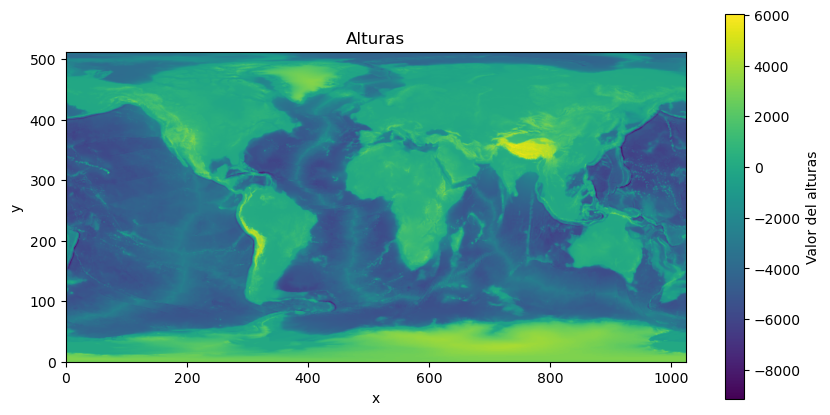

In [89]:
v=100
n=200
Y=np.linspace(-v,v,n)
X=np.linspace(-v,v,n)
alturas = np.loadtxt('altitudes.txt')
x,y = np.meshgrid(X,Y)

dis=50000
#esta acota los valores que puede tener la funcion 
c=9154
c2=6024
plt.figure(figsize=(10,5))
plt.title("Alturas")
#para imshow el primer termino es el del valor a graficar, el segundo es el valor maximo que puede alcanzar la función
#el tercero son los intervalos de nuestros que abarcara la imagen, el cmap. cambias el tipo de formato de color para mejor visualización.
plt.imshow(alturas,vmax=c2,vmin=-c,extent=(0,1024,0,512), cmap ='viridis')
plt.colorbar(label='Valor del alturas')
plt.xlabel('x')
plt.ylabel('y')

**b)** Ahora, usando tus valores para las derivadas, calcula la intensidad para cada
punto de la cuadrıcula, con $\varphi = 45^o$, y haz un grafico de densidad de los valores resultantes en el que el brillo de cada punto depende de la correspondiente valor de intensidad. Si lo haces funcionar correctamente, la grafica deberıa verse como un mapa en relieve del mundo; deber ́ıas poder ver los continentes y las cadenas montañosas en 3D. (Algunos de los problemas comunes al hacer esto, pueden ser: un mapa que esta al reves o de lado, o un mapa en el que el relieve que esta ́“de adentro hacia afuera”, lo que significa que las regiones altas se ven bajas y viceversa. Trabaja con los detalles de tu programa hasta que obtiengas un mapa que te parezca adecuado.) Hint: Ten en cuenta que el valor de la intensidad I de la formula anterior puede ser positivo o negativo; oscila entre  ́ +1 y −1. ¿Que significa una intensidad negativa? Significa que el area en cuestion esta en sombras (es decir, que se encuentra en el lado equivocado de la montana para recibir alguna luz). Podrıas representar esto coloreando esas areas del mapa completamente de negro, aunque en la practica obtendras una imagen mas bonita (aunque tal vez menos realista) simplemente usando una gama continua de grises desde $+1$ hasta $−1$.

In [65]:
def Parciales(P,h):
    """
    Ciclos for para recorrer toda la matriz y hacer las derivadas con sus respectivos puntos
    """
    Dimensiony , Dimensionx =P.shape
    #se agregan listas para almacenar datos a Y constante
    Parcial_X=[]
    Parcial_Y=[]
    for y in range(Dimensiony):
      #se agregan listas vacias para X variable
      PX=[]
      PY=[]

      for x in range(Dimensionx):
        i=y
        j=x
          
        """
        Los .append son para agregar los datos obtenidos
        P[y,x] son los valores obtenidos del potencial representados en una matriz.
        el 2*h viene por la consideracion de la derivada central ocupando como H=2*h dado que estan bien establecidos nuestros intervalos una vez evaluando los datos del potencial.
        """
        if i==0:
          if j==0:
            #print("i derecha j derecha "+str(i)+" "+str(j))
            Parcial_y = float((P[j+1][j]-P[i][j])/(h))
            Parcial_x = float((P[i][j+1]-P[i][j])/(h))
            PX.append(Parcial_x)
            PY.append(Parcial_y)
          elif j==Dimensionx-1:
            #print("i derecha j izquierda " +str(i)+" "+str(j))
            Parcial_y = float((P[i+1][j]-P[i][j])/(h))
            Parcial_x = float((P[i][j]-P[i][j-1])/(h))
            PX.append(Parcial_x)
            PY.append(Parcial_y)
          else :
            #print("i derecha j central " +str(i)+" "+str(j))
            Parcial_y = float((P[i+1][j]-P[i][j])/(h))
            Parcial_x = float((P[i][j+1]-P[i][j-1])/(2*h))
            PX.append(Parcial_x)
            PY.append(Parcial_y)
            #print(y[i][j])
        elif i==Dimensiony-1:
          if j==0:
            #print("i izquierda j derecha "+str(i)+" "+str(j))
            Parcial_y = float((P[i][j]-P[i-1][j])/(h))
            Parcial_x = float((P[i][j+1]-P[i][j])/(h))
            PX.append(Parcial_x)
            PY.append(Parcial_y)
          elif j==Dimensionx-1:
            #print("i izquierda j izquierda "+str(i)+" "+str(j))
            Parcial_y = float((P[i][j]-P[i-1][j])/(h))
            Parcial_x = float((P[i][j]-P[i][j-1])/(h))
            PX.append(Parcial_x)
            PY.append(Parcial_y)
          else:
            Parcial_y = float((P[i][j]-P[i-1][j])/(h))
            Parcial_x = float((P[i][j+1]-P[i][j-1])/(2*h))
            PX.append(Parcial_x)
            PY.append(Parcial_y)
        elif 0 < i < Dimensiony-1:
          if j==0:
            Parcial_y = float((P[i+1][j]-P[i-1][j])/(2*h))
            Parcial_x = float((P[i][j+1]-P[i][j])/(h))
            PX.append(Parcial_x)
            PY.append(Parcial_y)
          elif j==Dimensionx-1 :
            Parcial_y = float((P[i+1][j]-P[i-1][j])/(2*h))
            Parcial_x = float((P[i][j]-P[i][j-1])/(h))
            PX.append(Parcial_x)
            PY.append(Parcial_y)
          elif 0 < j< Dimensionx-1:
            Parcial_y = float((P[i+1][j]-P[i-1][j])/(2*h))
            Parcial_x = float((P[i][j+1]-P[i][j-1])/(2*h))
            PX.append(Parcial_x)
            PY.append(Parcial_y)
      Parcial_X.append(PX)
      Parcial_Y.append(PY)
    return Parcial_X,Parcial_Y

Text(0, 0.5, 'y')

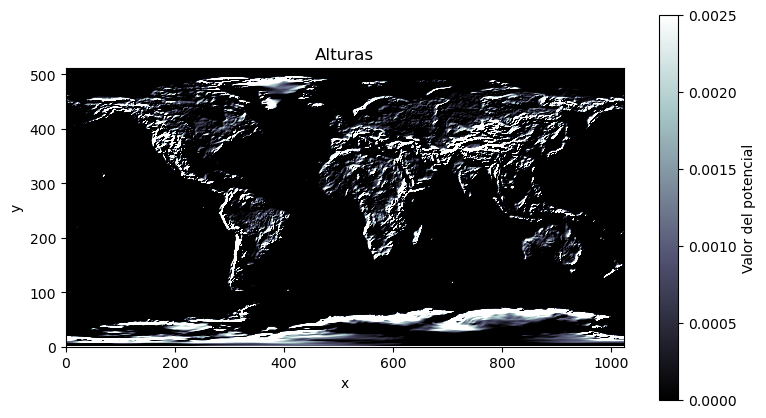

In [73]:
alturas = np.loadtxt('altitudes.txt')
alturas2 = np.maximum(alturas, 0)

h=30000
Parciales_2=Parciales(alturas2,h)
Parcial_x=np.array(Parciales_2[0])
Parcial_y=np.array(Parciales_2[1])
#calculamos la intensidad
phi = np.radians(45)
I = (np.cos(phi)*Parcial_x + np.sin(phi)*Parcial_y) /(np.sqrt(Parcial_x**2 + Parcial_y**2 + 1))  # valores entre -1 y +1

#esta acota los valores que puede tener la funcion 
n=10
c=.025
c=c/n
plt.figure(figsize=(9,5))
plt.title("Alturas")

plt.imshow(I,vmax=c,vmin=-0,extent=(0,1024,0,512), cmap = 'bone')
plt.colorbar(label='Valor del potencial')
plt.xlabel('x')
plt.ylabel('y')

**c)** El otro archivo adjunto llamado stm.txt, contiene una cuadrıcula con valores
de mediciones de un microscopio de efecto tunel (scanning tunneling microscope o
**STM**) de la superficie $(111)$ del silicio. Un microscopio de efecto tunel (\textbf{STM}) es un
dispositivo que mide la forma de superficies a nivel atomico siguiendo una punta afilada sobre la superficie y midiendo la corriente de efecto tunel cuantico en funcion de la posicion. El resultado final es una cuadrıcula de valores que representan la
altura de la superficie en funcion de la posicion y los datos del archivo  stm.txt contienen precisamente esa rejilla de valores. Modifica tu programa anterior para visualizar los datos **STM** y ası crear una imagen **3D** de como se ve la superficie de silicio. El valor de h para las derivadas en este caso es de alrededor de $h = 2.5$ (en unidades arbitrarias).

In [91]:
w = np.loadtxt('stm.txt') # Cargamos los datos 

In [93]:
def calcular_derivadas(w, dx, dy):
    ny, nx = w.shape
    dw_dx = np.zeros_like(w)
    dw_dy = np.zeros_like(w)
    
    # Diferencias centradas en el interior
    for j in range(1, ny-1):
        for i in range(1, nx-1):
            dw_dx[j, i] = (w[j, i+1] - w[j, i-1]) / (2*dx)
            dw_dy[j, i] = (w[j+1, i] - w[j-1, i]) / (2*dy)

    # Bordes (diferencias unilaterales)
    for j in range(ny):
        dw_dx[j, 0] = (w[j, 1] - w[j, 0]) / dx
        dw_dx[j, nx-1] = (w[j, nx-1] - w[j, nx-2]) / dx
        
    for i in range(nx):
        dw_dy[0, i] = (w[1, i] - w[0, i]) / dy
        dw_dy[ny-1, i] = (w[ny-1, i] - w[ny-2, i]) / dy
    
    return dw_dx, dw_dy

/tmp/ipykernel_30563/3106462245.py:10: RuntimeWarning: invalid value encountered in sqrt
  denominador = np.sqrt(dwdx*2 + dwdy*2 + 1.0)


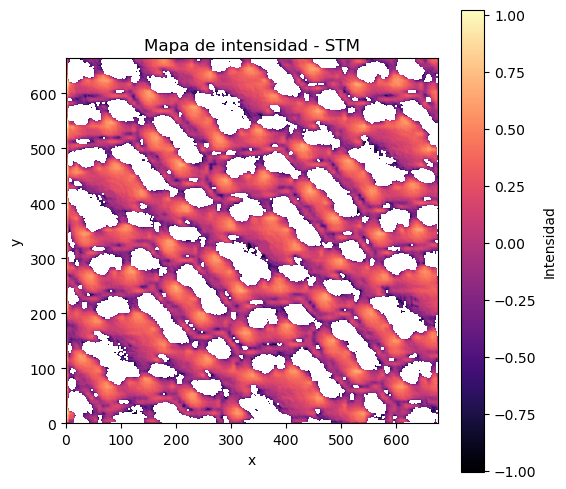

In [97]:
dx = 1
dy = 1


dwdx, dwdy = calcular_derivadas(w, dx, dy)


phi = np.radians(45) #a 45 grados como querian
numerador = np.cos(phi)*dwdx + np.sin(phi)*dwdy
denominador = np.sqrt(dwdx*2 + dwdy*2 + 1.0)
I = numerador / denominador   


ny, nx = w.shape
plt.figure(figsize=(6,6))


plt.imshow(I, 
           cmap='magma', 
           origin='lower', 
           extent=[0, dx*nx, 0, dy*ny])

plt.colorbar(label='Intensidad')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Mapa de intensidad - STM')
plt.show()